# Create video with fly on ball, brain activity, and fly behavior 

## Imports

In [79]:
from pathlib import Path
import os.path
from datetime import datetime
import pickle
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import CenteredNorm 
import numpy as np
import warnings
import cv2
import pingouin


from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis
from gulp2p.preproc import utils as utils
from gulp2p.preproc import ImagingPreProc as iPP
from gulp2p.preproc import ROIs as ROIs

## How do I create a video with python?

https://matplotlib.org/stable/users/explain/animations/animations.html


### Files:

In [80]:
fictrac_video_path = Path(r"Z:\Live Fly Imaging data\fictrac\fictrac-dbg-20240103_102052.avi")
behavioral_path = Path()
imaging_path = Path()
synced_bhv_img_path = Path(r"Z:\2PImaging\Kerstin\MIMS\20231207\20231207_DR019xiGluSnFr_Fly1_00001.p")

In [81]:
with open(synced_bhv_img_path, 'rb') as pkl:
    exptDat = pickle.load(pkl)
expDf = exptDat['expDf']

### Read Video:

In [82]:
def get_video_metadata(cap):
    metadata = {}
    # https://docs.opencv.org/4.x/d4/d15/group__videoio__flags__base.html
    # https://docs.opencv.org/4.x/d4/d15/group__videoio__flags__base.html#ggaeb8dd9c89c10a5c63c139bf7c4f5704da7c2fa550ba270713fca1405397b90ae0
    metadata['width']  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    metadata['height'] = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    metadata['frame_count'] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    metadata['fps'] = cap.get(cv2.CAP_PROP_FPS)
    metadata['bitrate'] = cap.get(cv2.CAP_PROP_BITRATE)
    if cap.get(cv2.CAP_PROP_CONVERT_RGB) == 1:
        metadata['channels'] = 3
    return metadata

def read_video_cv2(video_path):
    cap = cv2.VideoCapture(video_path)
    metadata = get_video_metadata(cap)
    shape = (metadata['frame_count'], metadata['height'], metadata['width'], metadata['channels'])
    # shape = (metadata['frame_count'], metadata['height'], metadata['width'])
    video = np.empty(shape=shape)
    i=0
    while cap.isOpened() and i<metadata['frame_count']:
        ret, frame = cap.read()
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        video[i,:] = frame
        i+=1
    cap.release()
    return video.astype(int), metadata

In [83]:
video, metadata = read_video_cv2(fictrac_video_path.as_posix())

In [84]:
metadata

{'width': 640,
 'height': 480,
 'frame_count': 601,
 'fps': 328.084,
 'bitrate': 1485.0,
 'channels': 3}

In [85]:
video.shape

(601, 480, 640, 3)

In [86]:
vid_length = metadata['frame_count'] / metadata['fps']
fm_interval = 1/metadata['fps']
fm_interval_ms = fm_interval*1000

In [87]:
print(vid_length)

1.831847941380866


## Plot

In [103]:
def align_bumps(deltaf_df, mean_rois=None, min_r = 0, offset=0, shift_peak_flor=False, use_max_as_peak=False):
    aligned_bumps = deltaf_df.copy()

    if mean_rois is None:
        mean_rois = get_mean_rois(aligned_bumps, precise=False)

    if min_r > 0:
        circ_rs = get_circ_rs(aligned_bumps)
        filter_mean_rois(mean_rois, circ_rs)

    for frame, mean_roi in enumerate(mean_rois):

        roll_amount = -1 * mean_roi + offset
        aligned_bump = np.roll(aligned_bumps[frame, :], roll_amount)
        if shift_peak_flor:
            if use_max_as_peak:
                peak_deltaf = np.max(aligned_bump)
            else:
                peak_deltaf = aligned_bump[offset]
            aligned_bump += 1 - peak_deltaf
        aligned_bumps[frame, :] = aligned_bump

        # if frame < 10:
        #     print(mean_roi)
        #     print(peak_deltaf)
        #     print(aligned_bump)

    return aligned_bumps

def get_roi_angles(num_rois):
    """Given the number of rois in one PB arm return a list sequentially assigning each roi to an angle

    Args:
        num_rois (int): number of rois in one PB arm (or in full EB)

    Returns:
        NDArray: Returns a list where at index i it has the angle for ROI i. 
    """
    return np.linspace(0,(2*np.pi),num_rois, endpoint=False)

def angle_roi_to_radians(roi_angle, low=0, high=8):
    return roi_angle/(high-low) * 2*np.pi

def angle_radians_to_roi(rad_angle, num_roi):
    roi_angle = rad_angle/(2*np.pi) * num_roi
    return roi_angle

def get_mean_roi(roi_weights, precise=False):
    num_rois = len(roi_weights)
    angles = get_roi_angles(num_rois)
    circ_mean_rad = pingouin.circ_mean(angles=angles, w=roi_weights)
    if circ_mean_rad < 0:
        circ_mean_rad += 2*np.pi
    roi_angle = angle_radians_to_roi(circ_mean_rad, num_rois)
    if not precise:
        roi_angle = round(roi_angle)
    return roi_angle

def get_mean_rois(deltaf_df, precise=False):
    num_frames, num_rois = deltaf_df.shape
    angles = np.repeat(np.expand_dims(get_roi_angles(num_rois), axis=0), num_frames, axis=0)
    circ_mean_rad = pingouin.circ_mean(angles=angles, w=deltaf_df, axis=1)
    # convert range -pi to pi into 0 to 2pi
    mask = (circ_mean_rad<0)
    circ_mean_rad[mask] += 2*np.pi

    roi_angle = angle_radians_to_roi(circ_mean_rad, num_rois)
    if not precise:
        roi_angle = np.round(roi_angle).astype(np.int32)
        roi_angle = roi_angle % num_rois
    return roi_angle

def get_circ_r(roi_weights):
    num_rois = len(roi_weights)
    angles = get_roi_angles(num_rois)
    return pingouin.circ_r(angles=angles, w=roi_weights)

def get_circ_rs(deltaf_df):
    num_frames, num_rois = deltaf_df.shape
    angles = np.repeat(np.expand_dims(get_roi_angles(num_rois), axis=0), num_frames, axis=0)
    return pingouin.circ_r(angles=angles, w=deltaf_df, axis=1)

def filter_mean_rois(mean_rois, circ_rs, min_r=0.15):
    # in place change
    if np.issubdtype(mean_rois.dtype , np.integer):
        empty_value = -1
    else:
        empty_value = np.nan
    
    mask = (circ_rs <  min_r)
    mean_rois[mask] = empty_value
    return mean_rois

def plot_heatmap(flor, axes=None, aspect=32, plot_cbar=True):
    if axes is None: 
        fig = plt.figure()
        ax = fig.add_subplot()
    else:
        ax = axes
        fig = axes.get_figure()

    im = ax.imshow(flor.T, aspect=aspect, interpolation='none', norm=CenteredNorm(), cmap='PiYG')
    ax.invert_yaxis()

    if plot_cbar:
        cbar = fig.colorbar(im, ax=ax, orientation='horizontal')
        # clim = [np.min(flor), np.max(flor)]
        # cbar.ax.set_ylim(clim)
        # if clim[0] < 0 < clim[1]:
        #     cbar.set_ticks([clim[0], 0, clim[1]])

    if axes is not None:
        return
    else:
        return fig, ax

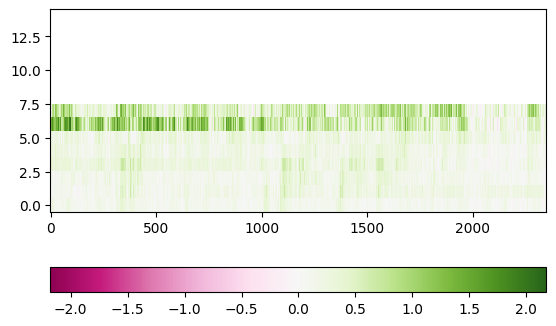

In [104]:

aligned_bumps = align_bumps(exptDat['DF_G'], min_r = 0.15, offset=0)
# aligned_bumps = align_bumps(upper_deltaf)

aligned_bumps

fig, ax = plt.subplots()

mean_rois = get_mean_rois(aligned_bumps, precise=True)
circ_rs = get_circ_rs(aligned_bumps)

mask = (circ_rs <  0.15)
mean_rois[mask] = None

# ax.plot(mean_rois, lw=0, marker='o', ms=0.5)

plot_heatmap(exptDat['DF_G'], axes=ax, aspect=64)

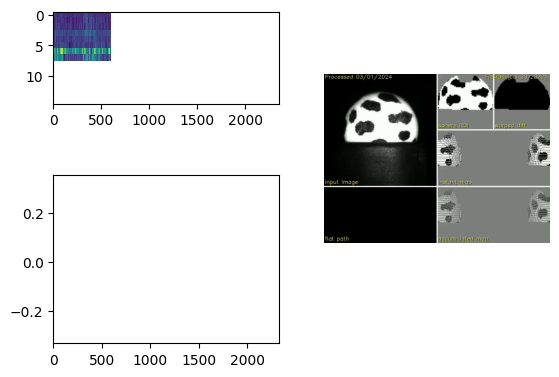

In [128]:
mosaic = [['flor', 'movie'],
          ['bhv', 'movie']]
fig, axd = plt.subplot_mosaic(mosaic=mosaic)

# Initial plot
flor = axd['flor'].imshow(exptDat['DF_G'].T[:, 0:2], aspect=64, interpolation='none')
bhv = axd['bhv'].plot(expDf['vRfilt'][0:2])[0]
mov = axd['movie'].imshow(video[0])

axd['movie'].set_axis_off()
axd['flor'].set_xlim([0, exptDat['DF_G'].shape[0]])
axd['bhv'].set_xlim([0, len(expDf['vRfilt'])])

def update(frame):
    # for each frame, update the data stored on each artist.
    mov.set_data(video[frame])
    bhv.set_xdata(range(frame))
    bhv.set_ydata(expDf['vRfilt'][:frame])
    axd['flor'].imshow(exptDat['DF_G'].T[:,:frame], aspect=64, interpolation='none')



ani = animation.FuncAnimation(fig=fig,
                              func=update,
                              frames=metadata['frame_count'],
                              interval=fm_interval_ms,
                              )
ani.save("../results/videos/animation_test.mp4",writer='ffmpeg') # Need to install ffmpeg (conda install -c conda-forge ffmpeg) 

In [127]:
exptDat['DF_G'].shape

(2350, 15)

In [123]:
metadata['frame_count']

601